In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lifelines

In [2]:
BATCH_SIZE = 100_000
SEED = 37
SAMPLE_PROPORTION = 0.001

In [3]:
member_batches = []
max_index = 0

for batch in pd.read_csv('../data/members_v3.csv', chunksize = BATCH_SIZE):
    member_batches.append(batch.sample(frac = SAMPLE_PROPORTION, random_state = SEED))
    if max(batch.index) + 1 > max_index:
        max_index = max(batch.index) + 1

sample_members = pd.concat(member_batches, ignore_index = True)
member_ids = set(sample_members['msno'])

print(f'{len(sample_members): ,} out of {max_index: ,} members selected.')
print()
print(sample_members.head())
print()
print(sample_members.info())

 6,769 out of  6,769,473 members selected.

                                           msno  city  bd  gender  \
0  59LT0TXKCMT0x8lBV6lihO8CvTZ9z5Sb9UsypwfC6Uk=     1   0     NaN   
1  +9WO11eKjgcyXUN4ewrT4Q00zTKY/fHbZgYaxZsSDt8=     1   0     NaN   
2  6P/ta5JtN8UDFiuHI2ELWXLaRUsgN97Zj63QAMWLycQ=     1   0     NaN   
3  0g6qJ7am8vecp54eFV7I0ceLy8yzHWJA0a32aNZM6YU=     1  21  female   
4  LVZhPn7ds6KtnZ1GPMHV4DFhCuYAiQtf4QucKYL2d9A=     1   0     NaN   

   registered_via  registration_init_time  
0               4                20161202  
1               9                20120208  
2               4                20161206  
3               3                20150414  
4               9                20150919  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6769 entries, 0 to 6768
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   msno                    6769 non-null   object
 1   city     

In [4]:
sample_members_typecast = sample_members.copy()

sample_members_typecast[['city', 'registered_via']] = sample_members_typecast[['city', 'registered_via']].astype('object')
sample_members_typecast['registration_init_time'] = pd.to_datetime(sample_members_typecast['registration_init_time'], format = '%Y%m%d')

print(sample_members_typecast.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6769 entries, 0 to 6768
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   msno                    6769 non-null   object        
 1   city                    6769 non-null   object        
 2   bd                      6769 non-null   int64         
 3   gender                  2325 non-null   object        
 4   registered_via          6769 non-null   object        
 5   registration_init_time  6769 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 317.4+ KB
None


In [5]:
transaction_batches = []

max_index_total = 0
for csv in ['../data/transactions.csv', '../data/transactions_v2.csv']:
    max_index = 0
    for batch in pd.read_csv(csv, chunksize = BATCH_SIZE):
        transaction_batches.append(batch[batch['msno'].isin(member_ids)])
        if max(batch.index) + 1 > max_index:
            max_index = max(batch.index) + 1
    max_index_total += max_index
    
sample_transactions = pd.concat(transaction_batches, ignore_index = True)

print(f'{len(sample_transactions): ,} out of {max_index_total: ,} transactions selected.')
print()
print(sample_transactions.head())
print()
print(sample_transactions.info())

 19,801 out of  22,978,755 transactions selected.

                                           msno  payment_method_id  \
0  9kW4ORgM/7pZ3O2i4/ACTkeyjt1keEpBRmcWiYEZHiU=                 41   
1  wcXslluldERi48gljH+9o9KgXgYsCt5ih8+i3EXUNIE=                 34   
2  mCQIOwBybuLG6L88zC65GiNd5jihPflNq03KWRYbA+c=                 40   
3  qaT4OYJ+gEbriiBlR29k4BUJeszVX8VxapTeUuO0xa4=                 40   
4  +6K9UdokGth8QGWvwpnmc4LIeLs1GDQUadRwli4D4ac=                 39   

   payment_plan_days  plan_list_price  actual_amount_paid  is_auto_renew  \
0                 30              149                 149              1   
1                 30              149                 149              1   
2                 30              149                 149              1   
3                 30              149                 149              1   
4                 30              149                 149              1   

   transaction_date  membership_expire_date  is_cancel  
0          201

In [6]:
sample_transactions_typecast = sample_transactions.copy()

sample_transactions_typecast['payment_method_id'] = sample_transactions_typecast['payment_method_id'].astype('object')
for column in ['transaction_date', 'membership_expire_date']:
    sample_transactions_typecast[column] = pd.to_datetime(sample_transactions_typecast[column], format = '%Y%m%d')
sample_transactions_typecast[['is_auto_renew', 'is_cancel']] = sample_transactions_typecast[['is_auto_renew', 'is_cancel']].astype('boolean')

print(sample_transactions_typecast.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19801 entries, 0 to 19800
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   msno                    19801 non-null  object        
 1   payment_method_id       19801 non-null  object        
 2   payment_plan_days       19801 non-null  int64         
 3   plan_list_price         19801 non-null  int64         
 4   actual_amount_paid      19801 non-null  int64         
 5   is_auto_renew           19801 non-null  boolean       
 6   transaction_date        19801 non-null  datetime64[ns]
 7   membership_expire_date  19801 non-null  datetime64[ns]
 8   is_cancel               19801 non-null  boolean       
dtypes: boolean(2), datetime64[ns](2), int64(3), object(2)
memory usage: 1.1+ MB
None


The oldest verified age in Taiwan is 111 years. Therefore, we assume that any of the ages between 1 and 111 are truthful, and ages outside that range are set to null.

In [7]:
sample = pd.merge(sample_members_typecast, sample_transactions_typecast, how = 'inner').drop_duplicates()\
    .drop(columns = ['payment_plan_days', 'plan_list_price', 'is_auto_renew'])

In [8]:
print(((sample['bd'] <= 0) | (sample['bd'] > 111)).mean())
print((sample['actual_amount_paid'] < 0).mean())
print(sample['gender'].unique())

0.4834082529420678
0.0
['male' 'female' nan]


In [9]:
sample2 = sample.copy()
sample2['bd'] = [None if x <= 0 or x > 111 else x for x in sample2['bd']]
print(sample2.info())

<class 'pandas.core.frame.DataFrame'>
Index: 19799 entries, 0 to 19800
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   msno                    19799 non-null  object        
 1   city                    19799 non-null  object        
 2   bd                      10228 non-null  float64       
 3   gender                  10138 non-null  object        
 4   registered_via          19799 non-null  object        
 5   registration_init_time  19799 non-null  datetime64[ns]
 6   payment_method_id       19799 non-null  object        
 7   actual_amount_paid      19799 non-null  int64         
 8   transaction_date        19799 non-null  datetime64[ns]
 9   membership_expire_date  19799 non-null  datetime64[ns]
 10  is_cancel               19799 non-null  boolean       
dtypes: boolean(1), datetime64[ns](3), float64(1), int64(1), object(5)
memory usage: 1.7+ MB
None


In [10]:
print('proportion of missing \'bd\' and \'gender\':')
print(((sample2['bd'].isna()) & (sample2['gender'].isna())).mean())
print()
print('proportion of missing \'bd\' only:')
print(((sample2['bd'].isna()) & (~ sample2['gender'].isna())).mean())
print()
print('proportion of missing \'gender\' only:')
print(((sample2['gender'].isna()) & (~ sample2['bd'].isna())).mean())

proportion of missing 'bd' and 'gender':
0.4747714531036921

proportion of missing 'bd' only:
0.008636799838375675

proportion of missing 'gender' only:
0.013182483963836557


In [78]:
sample3 = sample2.copy()
sample3[sample3['transaction_date'] <= sample3['membership_expire_date']]
sample3['membership_expire_date'] = np.where(sample3['is_cancel'], sample3['transaction_date'], sample3['membership_expire_date'])
sample3['missingness'] = np.where(
    sample3['gender'].isna(), 
    np.where(sample3['bd'].isna(), 'both_missing', 'gender_missing'), 
    np.where(sample3['bd'].isna(), 'bd_missing', 'complete')
)

print(sample3.head())

                                           msno city    bd gender  \
0  qaz4HIeGXgQBadgsauQ2JPC6mRAbgPEffBSgEdWOhzc=   15  29.0   male   
1  qaz4HIeGXgQBadgsauQ2JPC6mRAbgPEffBSgEdWOhzc=   15  29.0   male   
2  qaz4HIeGXgQBadgsauQ2JPC6mRAbgPEffBSgEdWOhzc=   15  29.0   male   
3  qaz4HIeGXgQBadgsauQ2JPC6mRAbgPEffBSgEdWOhzc=   15  29.0   male   
4  qaz4HIeGXgQBadgsauQ2JPC6mRAbgPEffBSgEdWOhzc=   15  29.0   male   

  registered_via registration_init_time payment_method_id  actual_amount_paid  \
0              7             2014-05-22                41                 149   
1              7             2014-05-22                41                 149   
2              7             2014-05-22                41                 149   
3              7             2014-05-22                41                 149   
4              7             2014-05-22                41                 149   

  transaction_date membership_expire_date  is_cancel missingness  
0       2016-05-21             

In [79]:
OBS_START = pd.to_datetime(20150101, format = '%Y%m%d')
OBS_END = pd.to_datetime(20170331, format = '%Y%m%d')

In [131]:
survival = sample3.copy().sort_values(by = ['msno', 'transaction_date'])

survival['start'] = (survival['transaction_date'] - survival['registration_init_time']).dt.days + 1
survival['end'] = [d if d < OBS_END else OBS_END for d in survival['membership_expire_date']]
survival['end'] = (survival['end'] - survival['registration_init_time']).dt.days + 1
survival['obs_end'] = (OBS_END - survival['registration_init_time']).dt.days + 1

survival['is_last_obs'] = survival.groupby('msno')['start'].transform(lambda x: x == x.max())
survival['event'] = (
    ((survival['end'] + 30 < survival['start'].shift(-1)) & (survival['msno'] == survival['msno'].shift(-1))) |
    ((survival['is_last_obs']) & (survival['end'] + 30 < survival['obs_end']))
)

survival['event_num'] = survival.groupby('msno')['event'].cumsum()
survival['tenure'] = survival.groupby('msno')['event_num'].shift(1, fill_value = 0) + 1

survival = survival\
    .groupby(['msno',
              'tenure',
              'city', 
              'bd', 
              'gender', 
              'registered_via', 
              'payment_method_id', 
              'missingness'], 
             dropna = False)\
    .agg({
        'actual_amount_paid': 'sum',
        'start': 'min',
        'end': 'max',
        'event': 'last'
    })\
    .reset_index()

survival = survival[survival['start'] < survival['end']]

print(survival.head())

                                           msno  tenure  city    bd  gender  \
0  ++M4G6SSlhINyHbCMt5KVjPdbDAZkaJ0a51FF8lGr04=       1     1   NaN     NaN   
1  ++bQ/m6G+0XALmzX6fVXZmJkTBL95sxh166sI/METug=       1    13  30.0    male   
2  +0soPX8fELBq0t5QfRLsWsEBQN1UOld6K+3MMeK4BWM=       1     4  43.0  female   
3  +0soPX8fELBq0t5QfRLsWsEBQN1UOld6K+3MMeK4BWM=       1     4  43.0  female   
4  +1B1xTeP8fVBaB5xaLx1Dtl37SFX6XMd/gMAXEIfAJI=       1    13  18.0  female   

   registered_via  payment_method_id   missingness  actual_amount_paid  start  \
0               7                 41  both_missing                1683      1   
1               9                 32      complete                3576   3328   
2               3                 32      complete                1072    391   
3               3                 38      complete                 298    769   
4               9                 38      complete                3576    289   

    end  event  
0   501  False  
1  3

<Axes: xlabel='timeline'>

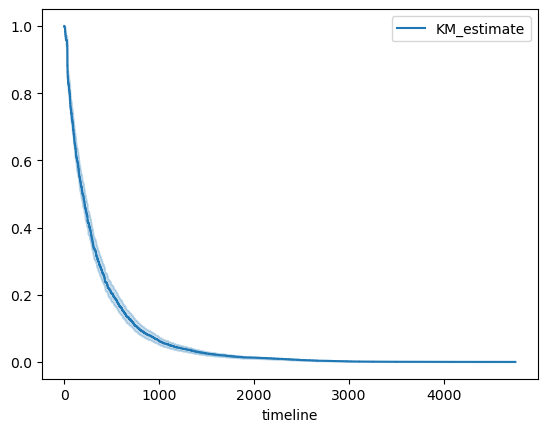

In [151]:
kmf = lifelines.KaplanMeierFitter()
kmf.fit(survival['end'], survival['event'], entry = survival['start'])
kmf.plot()